In [1]:
print("1. IMPORTING LIBRARIES")
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Explainability
import shap


1. IMPORTING LIBRARIES


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
print("2. LOAD AND INSPECT DATASET")
# Load dataset (replace path if needed)
df = pd.read_csv("C:/Users/User/Desktop/UTP\FYP LETSGO/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Overview
print(df.shape)
df.head()
df.info()


<>:3: SyntaxWarning: invalid escape sequence '\F'
<>:3: SyntaxWarning: invalid escape sequence '\F'
C:\Users\User\AppData\Local\Temp\ipykernel_19548\3848273930.py:3: SyntaxWarning: invalid escape sequence '\F'
  df = pd.read_csv("C:/Users/User/Desktop/UTP\FYP LETSGO/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")


2. LOAD AND INSPECT DATASET
(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

In [ ]:
print("3. DATA CLEANING")
# Remove customerID (not useful for prediction)
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Check duplicates
df.drop_duplicates(inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


3. DATA CLEANING


C:\Users\User\AppData\Local\Temp\ipykernel_24388\931858824.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
print("4. ENCODING AND SCALING")
# Label encode categorical features
cat_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Scale numerical features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])


4. ENCODING AND SCALING


In [ ]:
print("5. FEATURE ENGINEERING (enhance with time-like logic)")
# Create tenure category
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['<1yr', '1-2yr', '2-4yr', '4-6yr'])

# Encode the new feature
df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)

# Derived feature: average monthly spend per tenure
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# Replace inf/nan
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)


5. FEATURE ENGINEERING (enhance with time-like logic)


6. FEATURE SELECTION
AvgMonthlySpend                   0.154355
TotalCharges                      0.149377
MonthlyCharges                    0.141089
tenure                            0.139346
InternetService_Fiber optic       0.036832
PaymentMethod_Electronic check    0.031252
Contract_Two year                 0.029092
gender_Male                       0.024056
OnlineSecurity_Yes                0.023611
PaperlessBilling_Yes              0.023278
dtype: float64


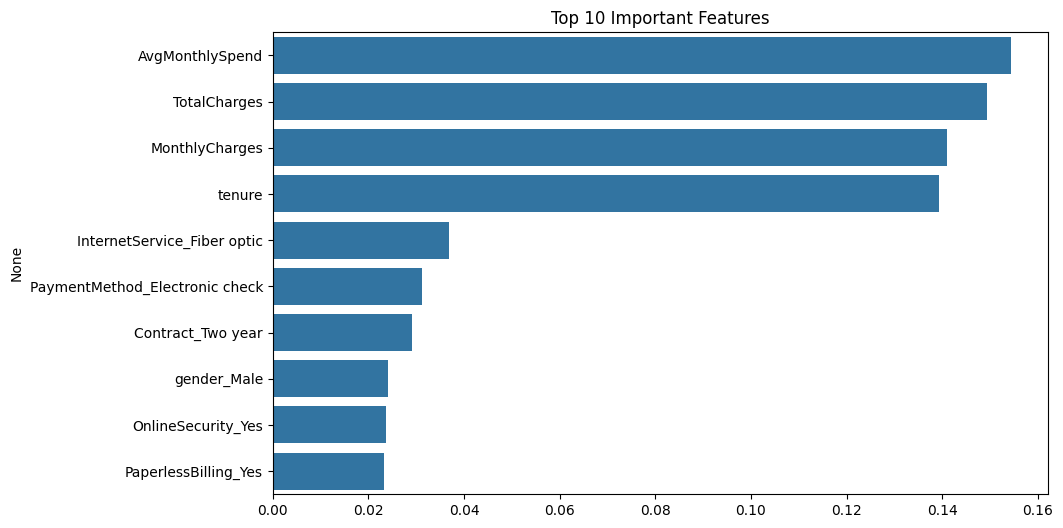

In [ ]:
print("6. FEATURE SELECTION")
# Feature importance using RandomForest
X = df.drop('Churn', axis=1)
y = df['Churn']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(10)
print(top_features)

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Important Features")
plt.show()


In [ ]:
print("7. SPLIT DATA")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


7. SPLIT DATA


In [ ]:
print("8. MODEL TRAINING AND TUNING")
models = {
    "Logistic Regression": LogisticRegression(max_iter=300),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

results_df = pd.DataFrame(results).T
print(results_df)


8. MODEL TRAINING AND TUNING
                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.792883   0.595016  0.542614  0.567608  0.846356
Decision Tree        0.767260   0.535817  0.531250  0.533524  0.776744
Random Forest        0.798577   0.621908  0.500000  0.554331  0.832535
XGBoost              0.779359   0.568182  0.497159  0.530303  0.811132


9. ROC Curve Visualization


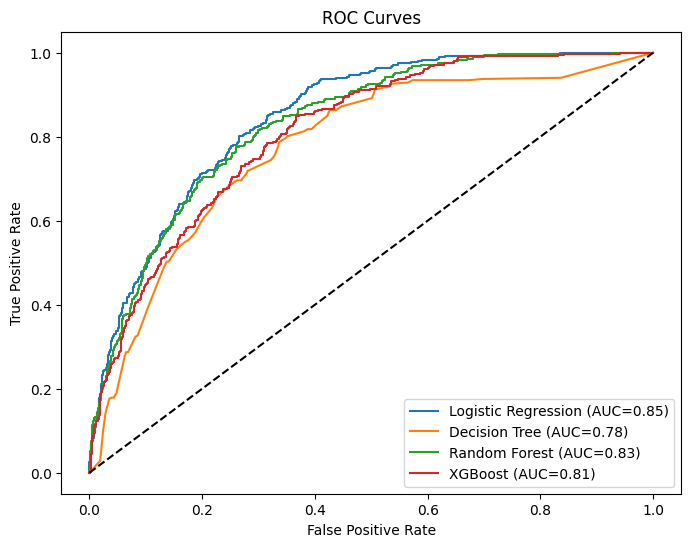

In [ ]:
print("9. ROC Curve Visualization")
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


10. MODEL EXPLAINABILITY WITH SHAP


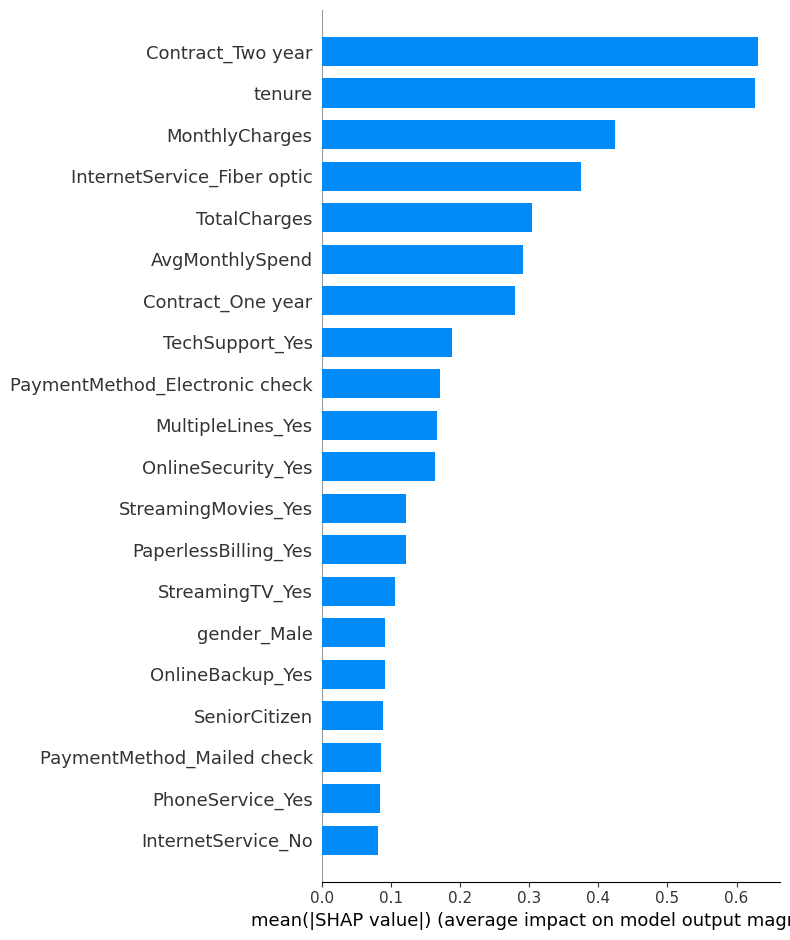

In [ ]:
print("10. MODEL EXPLAINABILITY WITH SHAP")
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")


In [ ]:
import pickle
from sklearn.linear_model import LogisticRegression

# 1️⃣ Train your best model
best_model = LogisticRegression(max_iter=300)
best_model.fit(X, y)

# 2️⃣ Save the list of features used during training
feature_list = X.columns.tolist()

# 3️⃣ Store both model and features together in one file
model_data = {
    "model": best_model,
    "features": feature_list
}

# 4️⃣ Save using pickle (no need to also use joblib — keep it consistent)
import os
os.makedirs("models", exist_ok=True)

with open("models/best_model.pkl", "wb") as file:
    pickle.dump(model_data, file)

print("✅ Model and feature list saved successfully at models/best_model.pkl")


✅ Model and feature list saved successfully at models/best_model.pkl


In [ ]:
import joblib
import pandas as pd

model = joblib.load("best_model.pkl")

# Get required columns from X_test
required_cols = X_test.columns

# Create a sample dict with all columns, set reasonable defaults
sample_dict = {col: 0 for col in required_cols}
sample_dict["tenure"] = 12
sample_dict["MonthlyCharges"] = 70
sample_dict["TotalCharges"] = 840

# If you want to set some categorical features, e.g.:
sample_dict["gender_Male"] = True
sample_dict["Partner_Yes"] = True
sample_dict["PhoneService_Yes"] = True
sample_dict["Contract_One year"] = True
sample_dict["PaperlessBilling_Yes"] = True

# Calculate AvgMonthlySpend as in feature engineering
sample_dict["AvgMonthlySpend"] = sample_dict["TotalCharges"] / (sample_dict["tenure"] + 1)

# Create DataFrame and ensure correct column order
sample = pd.DataFrame([sample_dict], columns=required_cols)

# Scale numerical features using the same scaler
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
sample[num_cols] = scaler.transform(sample[num_cols])

pred = model.predict(sample)
print("Prediction:", pred)

# Save feature list during training to ensure consistency

# After training your model
import joblib

feature_list = X.columns.tolist()

# Save both model and feature list
joblib.dump((best_model, feature_list), "best_model.pkl")


Prediction: [0]


['best_model.pkl']